In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    # ('0ujyio0h', r'SMM (2376999025)'): {},
    # ('4u72yqyy', r'SMM (649520)'): {},
    # ('t28il6r6', r'SMM (5113685)'): {},
    # ('4xn9hp3i', r'SMM (5543464)'): {},
    # ('7v067o2i', r'SMM (1663576)'): {},
    # ('nxk2yc20', r'SMM (1013721)'): {},
    # ('2oy25mfb', r'SMM (2347148)'): {},
    # ('pa3yuo5z', r'SMM (4141989)'): {},
    # ('j40y2hu0', r'SMM (179266)'): {},
    # ('ck1j2x5g', r'SMM (4824560)'): {},
    
    # ('0guis8gf', r'SMM (LInfty)'): {},
    ('2zpiq1ha', r'SMM (LInfty)'): {},
}
alt_id_to_label = dict(list(alt_ids))
label_to_alt_id = dict(map(reversed, alt_ids))
assert len(alt_ids) == len(label_to_alt_id), "Do two alt_id's have the same plot label?"

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('2zpiq1ha', 'SMM (LInfty)'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                            out_dir='/home/sci/ttransue/out/dafm',
                                            run_subdir='runs',
                                            prediction_filename='trajectories.parquet',
                                            device='cuda',
                                            alt_id='2zpiq1ha',
                                            rng_seed=2376999025,
                                            fit=True,
                                            id=44,
                                            dataset=Lorenz96(save_only_mean_std=True,
                                                             trajectory_stored_on_gpu_max_state_dimension=50,
                                                             state_dimension=1000000,
                                                             model_noise_std=0

In [5]:
trajectories = []
for k, v in tqdm(cfgs.items()):
    cfg = v['cfg']
    traj = (
        pl.scan_parquet(
            cfg.run_dir/cfg.prediction_filename,
        )
        .select(
            pl.col('*'),
            # pl.col(f'predicted_state_mean_dim_{dim_to_plot}'),
            # pl.col(f'predicted_state_std_dim_{dim_to_plot}'),
            alt_id=pl.lit(k[0]),
            Model=pl.lit(k[1]),
        )
        .collect()
    )
    lightning.pytorch.seed_everything(cfg.rng_seed)
    with lightning.pytorch.utilities.seed.isolate_rng():
        dynamics = datasets.get_dynamics_dataset(cfg.dataset, cfg.device)
    true_state = pl.DataFrame(
        dynamics.data['true_state'][:, 0].numpy(),
        schema=[f'true_state_dim_{d}' for d in range(dynamics.data['true_state'][:, 0].shape[1])],
    )
    trajectories.append(pl.concat([traj, true_state], how='horizontal'))

    del traj
    del true_state
    del dynamics

trajectories = pl.concat(trajectories)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [04:08<00:00, 248.50s/it]


In [6]:
trajectories.sort('times').tail(50).select(pl.col('predicted_state_mean_dim_0') - pl.col('true_state_dim_0'))

predicted_state_mean_dim_0
f32
0.427223
0.41033
0.390765
0.368346
0.342937
…
-0.045768
-0.048638
-0.051339


In [7]:
rmse = (
    trajectories.lazy()
    .select(
        pl.col('alt_id'), pl.col('Model'),
        pl.col('times'),
        pl.mean_horizontal(
            (
                pl.col(f'predicted_state_mean_dim_{d}') - pl.col(f'true_state_dim_{d}')
            ).pow(2)
            for d in range(cfg.dataset.state_dimension)
        ).sqrt().alias('RMSE(dim)'),
    )

    # take last time steps
    .sort('times')
    .group_by('alt_id', 'Model')
    .tail(50)

    .group_by('alt_id', 'Model')
    .agg(pl.col('RMSE(dim)').mean().alias('Mean(time) RMSE(dim)'))
    .collect()
)
print(rmse.mean())
rmse

shape: (1, 3)
┌────────┬───────┬──────────────────────┐
│ alt_id ┆ Model ┆ Mean(time) RMSE(dim) │
│ ---    ┆ ---   ┆ ---                  │
│ str    ┆ str   ┆ f32                  │
╞════════╪═══════╪══════════════════════╡
│ null   ┆ null  ┆ 0.32172              │
└────────┴───────┴──────────────────────┘


alt_id,Model,Mean(time) RMSE(dim)
str,str,f32
"""2zpiq1ha""","""SMM (LInfty)""",0.32172


In [8]:
(
    trajectories.lazy()
    .select(
        pl.selectors.starts_with('predicted_state_mean_dim_').abs().max()
    )
    .collect()
    .max_horizontal()
)

max
f32
16.651043


In [9]:
dim_to_plot = 0
plot_identifier = 'Model'
if plot_identifier == 'alt_id':
    row_order = list(alt_id_to_label)
elif plot_identifier == 'Model':
    row_order = list(label_to_alt_id)
else:
    raise ValueError(f'Unknown plot identifier: {plot_identifier}')
hue_order = row_order

In [10]:
def map_true_state_trajectory(plot):
    for (row, col, hue), _ in plot.facet_data():
        ax = plot.axes[row][col]
        data = (
            trajectories
            .filter(**{
                plot_identifier: plot.row_names[row],
            })
            .select(pl.col('times'), pl.col(f'true_state_dim_{dim_to_plot}').alias('State'))
            .to_pandas()
        )
        sns.lineplot(
            data=data,
            x='times',
            y='State',
            color='tab:gray',
            ax=ax,
            legend=False,
        )

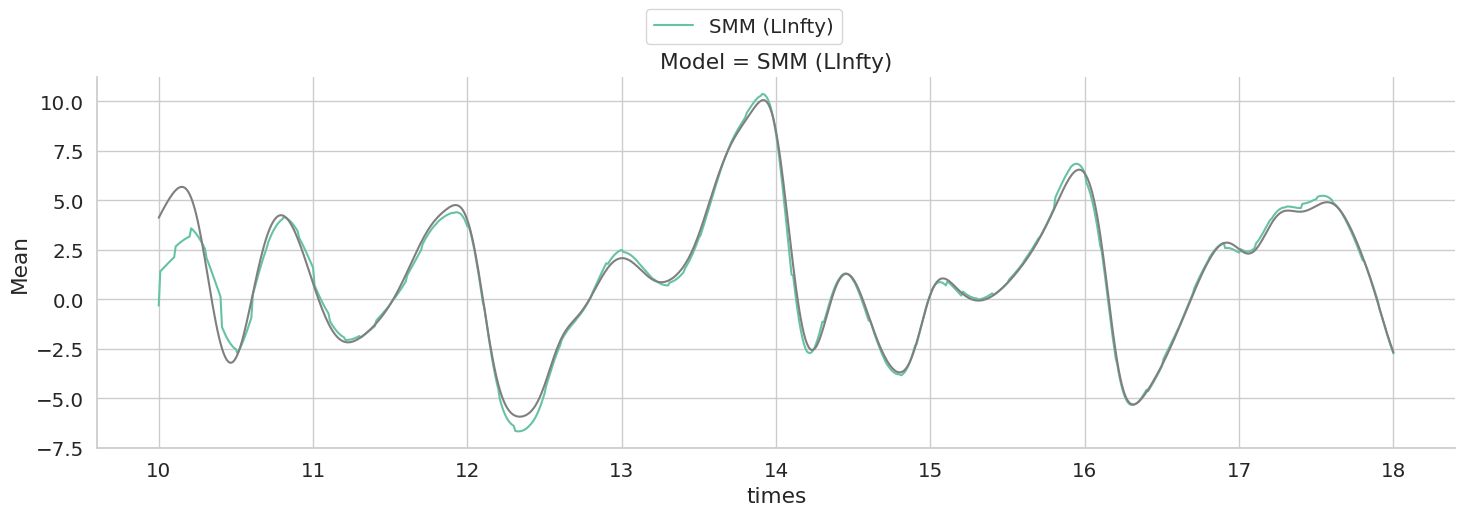

In [11]:
plot_predicted = (
    sns.relplot(
        kind='line',
        data=(
            trajectories
            .select(
                pl.col('times'),
                pl.col(plot_identifier),
                pl.col(f'predicted_state_mean_dim_{dim_to_plot}').alias('Mean'),
            )
            .to_pandas()
        ),
        x='times',
        y='Mean',
        row=plot_identifier,
        row_order=row_order,
        style=plot_identifier,
        hue=plot_identifier,
        hue_order=hue_order,
        aspect=3,
        zorder=2,
    )
    # .set(ylim=(-15, 15))
    # .set(xlim=(None, 32))
)
map_true_state_trajectory(plot_predicted)
sns.move_legend(
    plot_predicted,
    loc='upper center',
    ncol=min(len(alt_ids), 2) + 1,
    title='',
    bbox_to_anchor=(.455, 1.06),
    frameon=True,
    fancybox=True,
)
plot_predicted